# linear heatmap plot (Julia)

- `linear_heatmap` 実験の出力（`M_list.csv`, `N_list.csv`, `EVAL_T_list.csv`, `curves_long.csv`, `heat_t*.csv`）を可視化
- `softmax_heatmap/plot.ipynb` をベースにした構成
- **注意**: この版は軸スケール・カラースケールともに log を使わない（linear）


outdir = /home/takanami/cot_asymptotics/linear_heatmap/results/linear_heatmap_20260416_150619


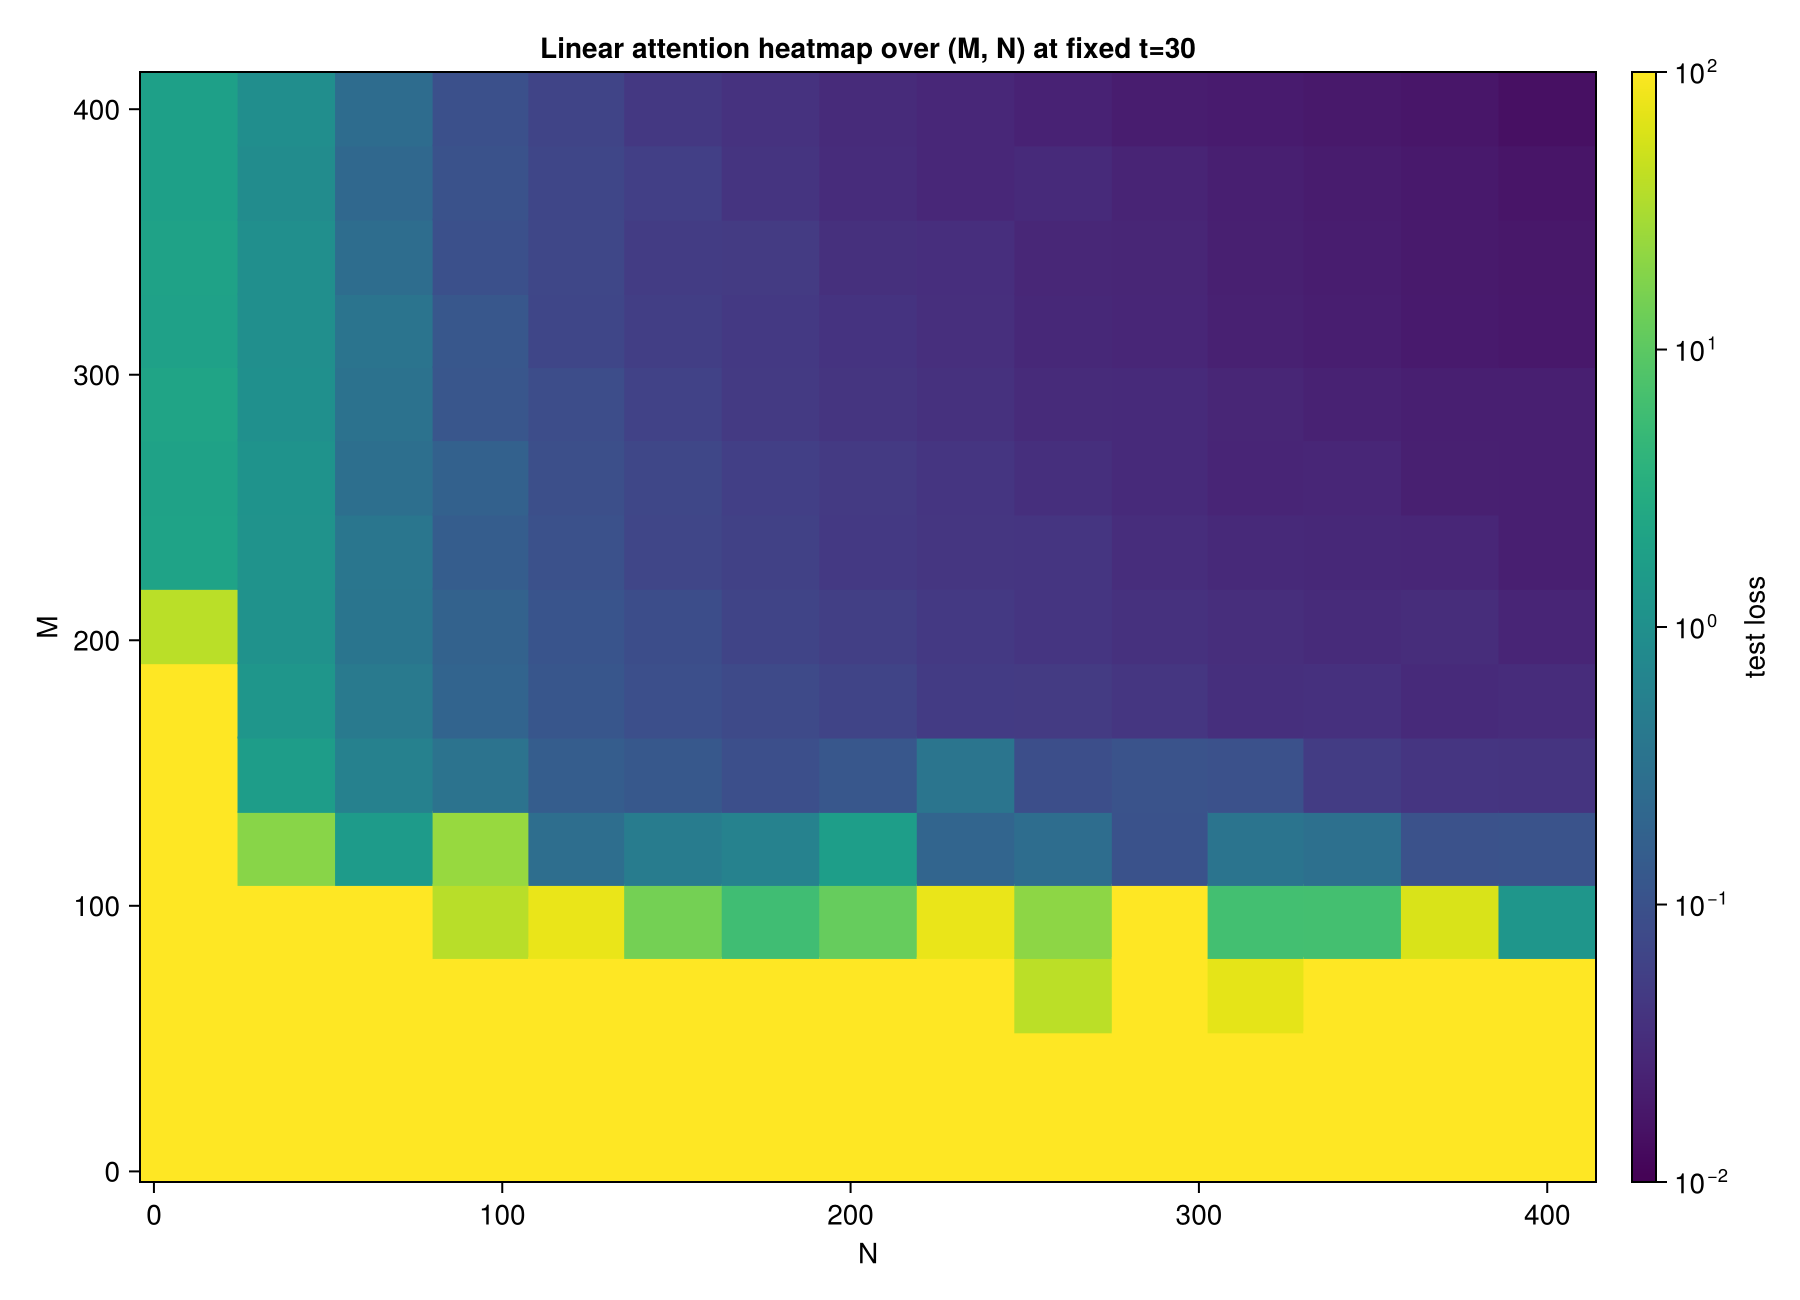

CairoMakie.Screen{IMAGE}


In [11]:
using CairoMakie
using DelimitedFiles

# 必要なら手動指定:
outdir = "/home/takanami/cot_asymptotics/linear_heatmap/results/linear_heatmap_20260416_150619"
#outdir = "/home/takanami/cot_asymptotics/linear_heatmap/results/latest_linear_heatmap"

println("outdir = ", outdir)

function read_vector_int(path::String)
    raw = readdlm(path, ',', Float64)
    vecf = vec(raw)
    return Int.(round.(vecf))
end

function read_t_heat_from_config(outdir::String; default_t::Int=30)
    cfg = joinpath(outdir, "config.txt")
    if !isfile(cfg)
        return default_t
    end
    for ln in eachline(cfg)
        if startswith(ln, "T_HEATMAP=")
            return parse(Int, split(ln, "=", limit=2)[2])
        end
    end
    return default_t
end

M_list = read_vector_int(joinpath(outdir, "M_list.csv"))
N_list = read_vector_int(joinpath(outdir, "N_list.csv"))
T_list = read_vector_int(joinpath(outdir, "EVAL_T_list.csv"))
#T_heat = read_t_heat_from_config(outdir)
T_heat = 30
@assert T_heat in T_list "T_heat=$(T_heat) is not in EVAL_T_list.csv"

curves_long = readdlm(joinpath(outdir, "curves_long.csv"), ',', Float64)

heat_path = joinpath(outdir, "heat_t$(T_heat).csv")
if isfile(heat_path)
    heat = readdlm(heat_path, ',', Float64)
else
    # heat ファイルが無ければ curves_long から t=T_heat を再構成
    heat = fill(NaN, length(M_list), length(N_list))
    for i in 1:size(curves_long, 1)
        m = Int(round(curves_long[i, 1]))
        n = Int(round(curves_long[i, 2]))
        t = Int(round(curves_long[i, 3]))
        err = curves_long[i, 4]
        if t == T_heat
            mi = findfirst(==(m), M_list)
            ni = findfirst(==(n), N_list)
            if !isnothing(mi) && !isnothing(ni)
                heat[mi, ni] = err
            end
        end
    end
end

fig = Figure(size = (900, 650))
ax = Axis(
    fig[1, 1],
    xlabel = "N",
    ylabel = "M",
    title = "Linear attention heatmap over (M, N) at fixed t=$(T_heat)"
)

# NOTE: linear版なので xscale/yscale/colorscale は設定しない
hm = heatmap!(ax, N_list, M_list, heat, colormap = :viridis, colorrange = (10^(-2), 10^2), colorscale = log10)
Colorbar(fig[1, 2], hm, label = "test loss")

display(fig)